# PROJECT: Credit Card Customer Segmentation
## Business Objective:
A bank wants to segment its credit card customers to:
* Identify high-value customers
* Detect inactive/churn-risk users
* Personalize offers
* Optimize marketing strategies

## ML Objective:
Use clustering algorithms to group customers based on:
* Spending behavior
* Transaction patterns
* Credit utilization
* Engagement level

## Learning Goals
- Understand clustering
- Apply K-Means, DBSCAN, Agglomerative Clustering
- Use Elbow Method
- Interpret clusters for business decisions

## Step 1: Import Dependencies

In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

## 1. Problem Statement

Banks have large customer bases but lack clear segmentation.

This project aims to cluster customers into meaningful groups
based on behavioral and financial features.

## 2. Data Understanding

In pandas, CSV (Comma-Separated Values) files are preferred over Excel (.xlsx, .xls) files primarily because they are plain text, lightweight, and significantly faster to read and write.

In [3]:
#Load dataset
dataset = pd.read_csv(r"C:\Users\M.faisal\Desktop\ai_ml\ai_ml_projects\3Logy-NDI-AI-ML-Crash\datasets\Credit_Card_Customer\BankChurners.csv")
dataset.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                                      

## IDENTIFY IMPORTANT FEATURES
To identify important features, let's Start With Business Understanding (ALWAYS FIRST).
Before touching code, ask:

> “What behaviors define a credit card customer?”

Let's think in **business dimensions**:

| Concept    | Meaning                |
| ---------- | ---------------------- |
| Spending   | How much money is used |
| Frequency  | How often card is used |
| Capacity   | Financial strength     |
| Risk       | Likelihood of churn    |
| Engagement | Activity level         |

This step is called:
**Feature relevance through domain understanding**

In [5]:
# Map Dataset Features to Business Meaning by inspecting column names:\
dataset.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='str')

## Interpretation of cloumns

| Feature                | Student Reasoning                        |
| ---------------------- | ---------------------------------------- |
| Total_Trans_Amt        | “Total amount spent → spending behavior” |
| Total_Trans_Ct         | “Number of transactions → activity”      |
| Credit_Limit           | “Maximum credit → capacity”              |
| Avg_Utilization_Ratio  | “How much of credit is used → behavior”  |
| Months_Inactive_12_mon | “Inactivity → engagement/churn risk”     |

This step is: **Feature semantic mapping**

Ask yourself:

> “If you were the bank, which variables would YOU care about?”

## 3. Exploratory Data Analysis (EDA)

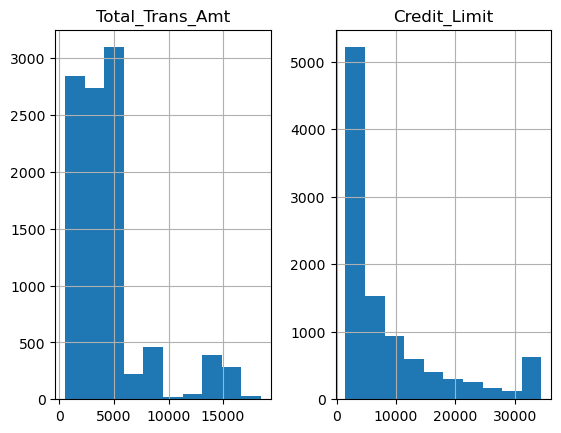

In [7]:
# A. Distribution Analysis
dataset[['Total_Trans_Amt', 'Credit_Limit']].hist();

Ask:
* Which features vary a lot?
* Which ones separate customers?

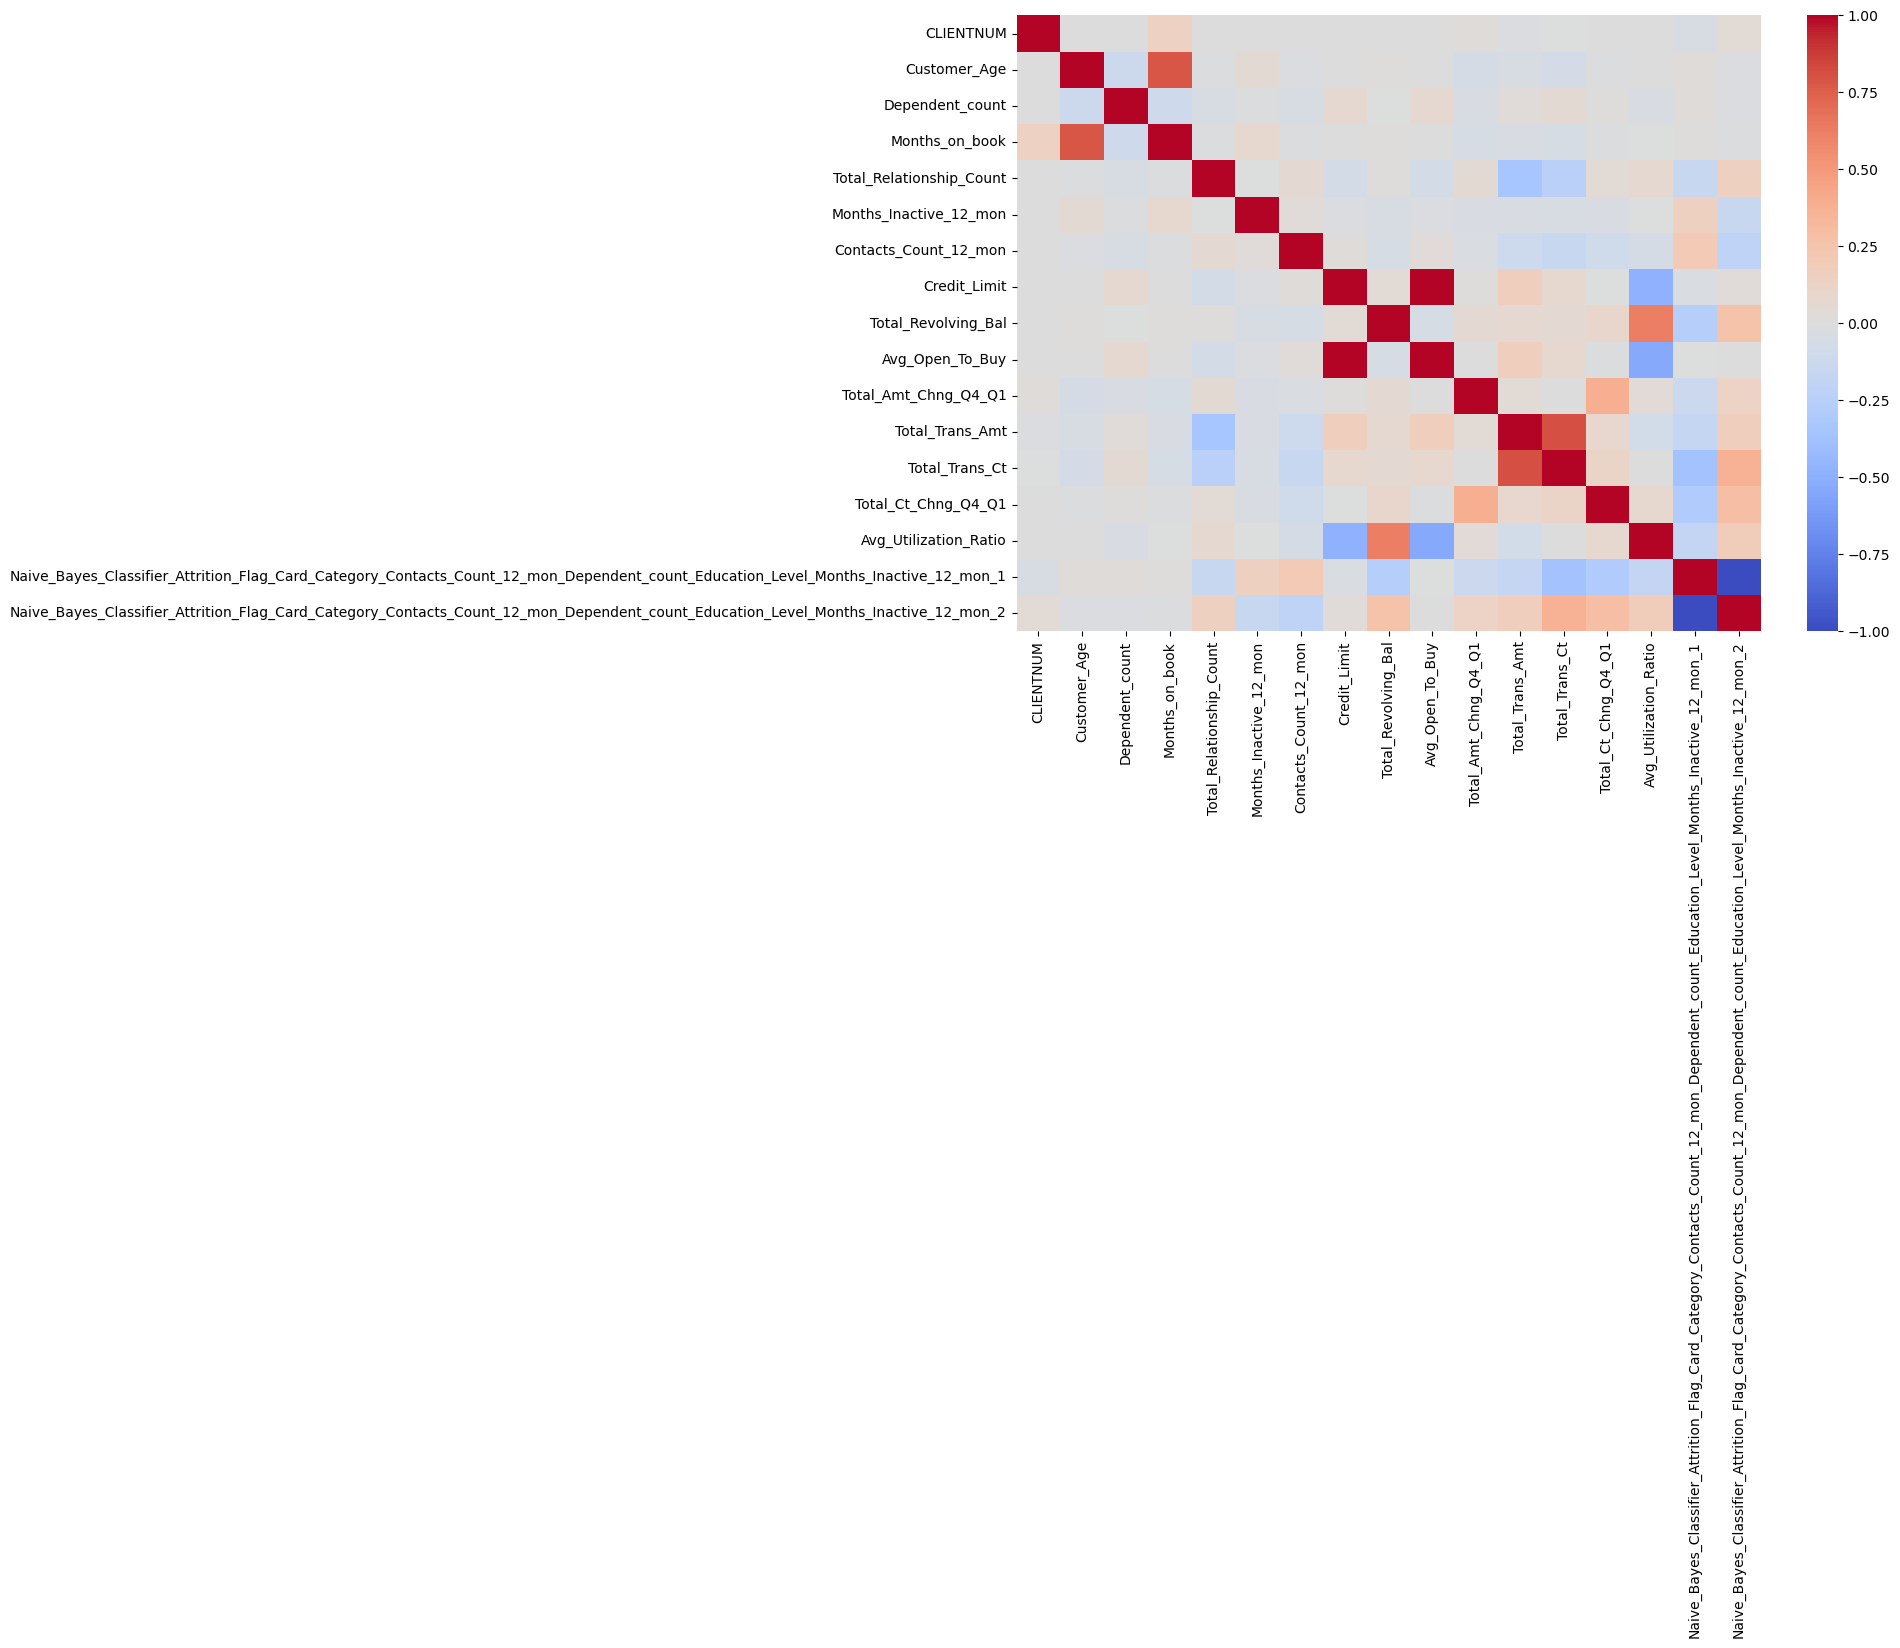

In [12]:
numeric_df = dataset.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

## WHAT A CORRELATION HEATMAP SHOWS?

A heatmap displays the **correlation between numerical features**.

Correlation ranges from:

* **+1** → strong positive relationship
* **0** → no relationship
* **–1** → strong negative relationship

---

## HOW TO INTERPRET IT?

---
### 1. Look at the Color First

Most heatmaps use:

* 🔴 **Red (or warm colors)** → strong positive correlation
* 🔵 **Blue (or cool colors)** → strong negative correlation
* ⚪ **Neutral/light color** → weak or no correlation

---

### 2. Focus on Strong Relationships
Note:
> “Ignore small values — focus on correlations above 0.6 or below -0.6”

---

### Case 1: Strong Positive Correlation

```text
Total_Trans_Amt ↔ Total_Trans_Ct
```
Interpretation:

* Customers who **spend more** also **transact more frequently**

Business meaning:

> High-value, active customers

---

### Case 2: Strong Negative Correlation

```text
Months_Inactive_12_mon ↔ Total_Trans_Ct
```
Interpretation:

* More inactive months → fewer transactions

Business meaning:

> Potential churn risk

---

### Case 3: Near Zero Correlation

```text
Credit_Limit ↔ Total_Trans_Ct
```
Interpretation:

* Credit limit does NOT strongly affect how often customers transact
Insight:

> Having money ≠ using it

---

### 3. Detect Redundant Features (VERY IMPORTANT)

If two features are highly correlated:

```text
Credit_Limit ↔ Avg_Open_To_Buy
```

They contain **similar information**

> “We don’t need both — this can affect clustering quality”

---

### 4. Identify Useful Clustering Features

Good clustering features:
Have:

* High variance
* Low redundancy
* Meaningful behavior

---
**Note**:
* Highly correlated features = redundant
* Independent features = useful

### WHAT IS VARIANCE?
Variance measures how much a feature spreads out (how much it changes).
* High variance → values are very different → useful for clustering
* Low variance → values are similar → not useful

In [14]:
# Low variance = useless for clustering
numeric_df = dataset.select_dtypes(include=['int64', 'float64'])
numeric_df.var().sort_values(ascending=False)

CLIENTNUM                                                                                                                             1.361889e+15
Avg_Open_To_Buy                                                                                                                       8.264056e+07
Credit_Limit                                                                                                                          8.260586e+07
Total_Trans_Amt                                                                                                                       1.154049e+07
Total_Revolving_Bal                                                                                                                   6.642044e+05
Total_Trans_Ct                                                                                                                        5.509616e+02
Customer_Age                                                                                                          

From the above output, Let's group the features into 4 categories:
1. EXTREMELY HIGH VARIANCE (which we'll REMOVE)

**Example**: (CLIENTNUM)
- This is just an ID column

- It has huge variance because every value is unique

**Problem**:
- It will completely distort clustering.
---
2. VERY HIGH VARIANCE FEATURES (scaling required)
    * Credit_Limit           → 8.26e+07
    * Avg_Open_To_Buy        → 8.26e+07
    * Total_Trans_Amt        → 1.15e+07
    * Total_Revolving_Bal    → 6.64e+05

    These features dominate because their values are large. “Clustering uses distance — large numbers dominate distance”

   **Without scaling*, Model will focus ONLY on these features
---
3. MODERATE VARIANCE (Good FEATURES)
    * Total_Trans_Ct          → 550
    * Customer_Age            → 64
    * Months_on_book          → 63
   
   These are:
    * Informative
    * Balanced
    * Useful for clustering
---
4. LOW VARIANCE FEATURES (May be USELESS)
    * Avg_Utilization_Ratio → 0.076
    * Total_Ct_Chng_Q4_Q1   → 0.056
    * Total_Amt_Chng_Q4_Q1  → 0.048
      
Values don’t change much across customers. “If everyone is similar, the feature can’t separate clusters”

---

### From the little Observation we did, we now know that we're keeping:
- Total_Trans_Amt
- Total_Trans_Ct
- Credit_Limit
- Total_Revolving_Bal
- Months_Inactive_12_mon
- Customer_Age

In [18]:
#Drop `CLIENTNUM` cloumn
dataset = dataset.drop([
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1"
], axis=1)

In [19]:
dataset.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Note; `Income_Category` can be useful — but only if handled correctly and with clear reasoning. Now let’s break it down:
**WHAT IS Income_Category?**

It looks like:

- Less than $40K
  
- $40K - $60K
  
- $60K - $80K
  
- $80K - $120K
  
- $120K +

- Unknown

This is an ordinal categorical feature (it has order).

---
### WHY IT CAN BE USEFUL?

Income influences:
- Spending power
- Credit usage
- Risk profile

So it helps answer:
| “Are high-income customers behaving differently?”

---
**BUT HERE’S THE CATCH**:

*Clustering algorithms*:
- Do NOT understand text
- Do NOT understand category order automatically, So if you do nothing `This will break or mislead the model`.

In [23]:
# Let's handle it using `Ordinal Encoding`
income_mapping = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0
}

dataset['Income_Category'] = dataset['Income_Category'].map(income_mapping)

In [24]:
dataset.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,3,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,1,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,4,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,1,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,3,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


**Scaling** in machine learning is a data pre-processing technique that transforms numerical features to a similar range or distribution. It prevents features with large magnitudes (e.g., salary) from dominating those with smaller magnitudes (e.g., age), ensuring models like KNN, SVM, and gradient descent algorithms perform accurately.

In [ ]:
# # Separate Numeric and Categorical Columns
# num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
# cat_cols = dataset.select_dtypes(include=['object']).columns

# # Preprocessing pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler, OneHotEncoder

# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), num_cols),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
# ])

# X_processed = preprocessor.fit_transform(dataset)

In [26]:
# Separate Numeric and Categorical Columns
num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
cat_cols = dataset.select_dtypes(include=['object', 'string']).columns

# Preprocessing pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
])

X_scaled = preprocessor.fit_transform(dataset)

In [28]:
X_scaled

array([[-0.16540558,  0.50336813,  0.62003891, ..., -0.97389518,
         3.8340026 , -0.77588223],
       [ 0.33357038,  2.04319867, -0.73629202, ..., -1.35734038,
        12.60857291, -0.61627565],
       [ 0.58305837,  0.50336813,  1.29820437, ..., -1.91120566,
         6.80786367, -0.99715499],
       ...,
       [-0.29014957, -1.03646242, -0.73629202, ..., -0.20700479,
         0.44430503, -0.99715499],
       [-2.03656544, -0.26654715, -0.05812655, ..., -0.12179474,
         0.04106963, -0.99715499],
       [-0.41489356, -0.26654715, -0.73629202, ..., -0.16439977,
        -0.26555729, -0.31157218]], shape=(10127, 15))

In [29]:
# Convert X_scaled to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols, index=dataset.index)

X_scaled_df.head()

,Customer_Age,Dependent_count,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,-0.165406,0.503368,0.620039,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,-0.959707,-0.973895,3.834003,-0.775882
1,0.333570,2.043199,-0.736292,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,-0.916433,-1.357340,12.608573,-0.616276
2,0.583058,0.503368,1.298204,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,-0.740982,-1.911206,6.807864,-0.997155
3,-0.789126,1.273283,-0.736292,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,-0.951758,-1.911206,6.807864,1.759686
4,-0.789126,0.503368,0.620039,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,-1.056263,-1.570365,7.509325,-0.997155


### Feature Engineering

In [33]:
# Let's do a bit of `Feature Engineering`
X_scaled_df['avg_transaction_value'] = X_scaled_df['Total_Trans_Amt'] / X_scaled_df['Total_Trans_Ct']
X_scaled_df.head()

,Customer_Age,Dependent_count,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_transaction_value
0,-0.165406,0.503368,0.620039,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,-0.959707,-0.973895,3.834003,-0.775882,0.985431
1,0.333570,2.043199,-0.736292,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,-0.916433,-1.357340,12.608573,-0.616276,0.675168
2,0.583058,0.503368,1.298204,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,-0.740982,-1.911206,6.807864,-0.997155,0.387704
3,-0.789126,1.273283,-0.736292,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,-0.951758,-1.911206,6.807864,1.759686,0.497988
4,-0.789126,0.503368,0.620039,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,-1.056263,-1.570365,7.509325,-0.997155,0.672623


### Final Selected Features

| Feature                | Why It Matters              |
| ---------------------- | --------------------------- |
| Total_Trans_Amt        | Captures spending power     |
| Total_Trans_Ct         | Captures usage frequency    |
| Credit_Limit           | Captures financial capacity |
| Avg_Utilization_Ratio  | Captures behavior pattern   |
| Months_Inactive_12_mon | Captures engagement         |
| Income_Category        | Captures Income category    |
|Total_Revolving_Bal     | Captoures the outstanding debt that rolls over month-to-month |

---
> “Feature importance in unsupervised learning is not given — it is **discovered**.”

In [35]:
X_final_df = X_scaled_df.loc[
    :,
    [
        'Customer_Age',
        'Total_Trans_Ct',
        'Credit_Limit',
        'Avg_Utilization_Ratio',
        'Months_Inactive_12_mon',
        'Income_Category',
        'Total_Revolving_Bal',
        'avg_transaction_value'
    ]
]
X_final_df.head()

,Customer_Age,Total_Trans_Ct,Credit_Limit,Avg_Utilization_Ratio,Months_Inactive_12_mon,Income_Category,Total_Revolving_Bal,avg_transaction_value
0,-0.165406,-0.973895,0.446622,-0.775882,-1.327136,0.620039,-0.473422,0.985431
1,0.333570,-1.357340,-0.041367,-0.616276,-1.327136,-0.736292,-0.366667,0.675168
2,0.583058,-1.911206,-0.573698,-0.997155,-1.327136,1.298204,-1.426858,0.387704
3,-0.789126,-1.911206,-0.585251,1.759686,1.641478,-0.736292,1.661686,0.497988
4,-0.789126,-1.570365,-0.430877,-0.997155,-1.327136,0.620039,-1.426858,0.672623


## FINAL SUMMARY
### Common Mistake to avoid:
* Use all features blindly
* Ignore meaning
* Skip scaling

### Correct mindset:
* Think first
* Analyze
* then model
---

To identify important features:
1. Understand the business problem
2. Interpret feature meanings
3. Analyze distributions & correlations
4. Remove low-value features
5. Validate experimentally




In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

`Income_Category`: That is not just another feature, it’s a demographic signal that can strongly influence:
- Credit usage
- Spending capacity
- Risk behavior

Dropping it may reduce the business interpretability of our clusters. So, we'll:

**Option 1**: Build TWO Models
- Model A: Behavioral Clustering (Numeric Only); Focus on pure financial behavior
- Model B: Enriched Clustering (Numeric + Categorical)
Add encoded Income_Category

Then compare:
* Cluster separation (silhouette)
* Business meaning
---
### Why This Matters?
Without Income:
- Clusters = “High spenders vs low spenders”

With Income:
- Clusters = “High-income high spenders” vs “Low-income high utilization (risk)”

That’s much more actionable

## Let's Define Our Evaluation Framework

For clustering, you mainly compare using:
- `Silhouette Score` is used which measures `How well-separated clusters are`.
- Inertia (ONLY for KMeans)
- Cluster Stability / Shape (visual + interpretation); Using PCA plots

In [36]:
# Prepare a Comparison Function
from sklearn.metrics import silhouette_score

def evaluate_model(name, labels, X):
    # Ignore noise labels for DBSCAN (-1)
    if len(set(labels)) > 1 and len(set(labels)) < len(X):
        score = silhouette_score(X, labels)
    else:
        score = -1

    return {
        "model": name,
        "silhouette_score": score,
        "n_clusters": len(set(labels)) - (1 if -1 in labels else 0)
    }

## Apply Clustering Models

We’ll use:
- KMeans
- Agglomerative
- DBSCAN

In [43]:
# KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels_km = kmeans.fit_predict(X_final_df)

results = []
labels_store = {}

labels_store["KMeans"] = labels_km
results.append(evaluate_model("KMeans", labels_km, X_final_df))

In [44]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_final_df)

labels_store["Agglomerative"] = labels_agg
results.append(evaluate_model("Agglomerative", labels_agg, X_final_df))

In [45]:
# DBSCAN
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.2, min_samples=5)
labels_db = db.fit_predict(X_final_df)

labels_store["DBSCAN"] = labels_db
results.append(evaluate_model("DBSCAN", labels_db, X_final_df))

## Evaluate Models

In [46]:
# Compare Results
results_df = pd.DataFrame(results)
results_df.sort_values(by="silhouette_score", ascending=False)

,model,silhouette_score,n_clusters
1,Agglomerative,0.816226,4
0,KMeans,0.720087,4
2,DBSCAN,-0.105005,11


In [47]:
# Pick Best Model
best_model_name = results_df.sort_values(
    by="silhouette_score",
    ascending=False
).iloc[0]["model"]

best_labels = labels_store[best_model_name]

## Visualization using PCA

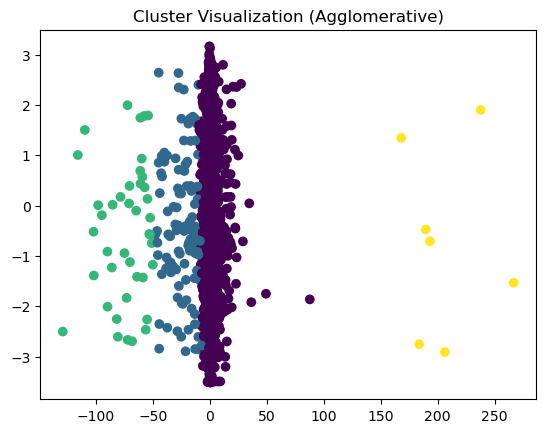

In [48]:
# PCA Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final_df)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels)
plt.title(f"Cluster Visualization ({best_model_name})")
plt.show()

## Business Interpretation

- Cluster 0: High volume buyers
- Cluster 1: Frequent small buyers
- Cluster 2: Irregular customers
- Cluster 3: Premium clients


In [49]:
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# inertia = []
# k_range = range(1, 10)

# for k in k_range:
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     kmeans.fit(X_final_df)
#     inertia.append(kmeans.inertia_)

# plt.plot(k_range, inertia, marker='o')
# plt.title('Elbow Method')
# plt.xlabel('Number of clusters')
# plt.ylabel('Inertia')
# plt.show()

## 🔹 Step 4: Apply Clustering Models

In [50]:
# from sklearn.cluster import DBSCAN, AgglomerativeClustering

# kmeans = KMeans(n_clusters=4, random_state=42)
# kmeans_labels = kmeans.fit_predict(X_scaled)

# dbscan = DBSCAN(eps=0.5, min_samples=5)
# dbscan_labels = dbscan.fit_predict(X_scaled)

# agg = AgglomerativeClustering(n_clusters=4)
# agg_labels = agg.fit_predict(X_scaled)

## 🔹 Step 5: Evaluate Models

In [ ]:
# from sklearn.metrics import silhouette_score

# print('KMeans:', silhouette_score(X_scaled, kmeans_labels))
# print('Agglomerative:', silhouette_score(X_scaled, agg_labels))

## 🔹 Step 6: Visualization using PCA

In [ ]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
# plt.title('Clusters Visualization')
# plt.show()